# Activity Classification with Multi-Sensor Fusion
Classes:

0 : Rest 

1 : Physical Activity

2 : Intense Physical Activity

Main dataset: PAMAP2

Real features: IMU + Heart Rate

Synthetic features (temporary): EMG + Temperature

1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

2. Config cell

In [4]:
WINDOW_SIZE = 200
STEP_SIZE = 100
RANDOM_STATE = 42

LABEL_NAMES = {
    0: "rest",
    1: "physical_activity",
    2: "intense_physical_activity"
}

3. Load PAMAP2 data

In [10]:
columns = [
    "timestamp",
    "activity_id",
    "heart_rate",

    # hand
    "temp_hand",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand"
]

df = pd.read_csv("../data/raw/PAMAP2_Dataset/Protocol/subject101.dat", sep=" ", header=None)

# keep only needed columns
df = df.iloc[:, :len(columns)]
df.columns = columns

df.head()

,timestamp,activity_id,heart_rate,temp_hand,acc_x_hand,acc_y_hand,acc_z_hand,gyro_x_hand,gyro_y_hand,gyro_z_hand
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295


4. Map PAMAP2 activities to the 3 classes

In [11]:
pamap2_activity_map = {
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "nordic_walking",
    12: "ascending_stairs",
    13: "descending_stairs",
    16: "vacuum_cleaning",
    17: "ironing",
    24: "rope_jumping"
}

three_class_map = {
    "lying": 0,
    "sitting": 0,

    "standing": 1,
    "walking": 1,
    "nordic_walking": 1,
    "ascending_stairs": 1,
    "descending_stairs": 1,
    "vacuum_cleaning": 1,
    "ironing": 1,

    "running": 2,
    "cycling": 2,
    "rope_jumping": 2
}

df["activity_name"] = df["activity_id"].map(pamap2_activity_map)
df = df[df["activity_name"].notna()].copy()
df["label"] = df["activity_name"].map(three_class_map)

df[["activity_id", "activity_name", "label"]].head()

,activity_id,activity_name,label
2928,1,lying,0
2929,1,lying,0
2930,1,lying,0
2931,1,lying,0
2932,1,lying,0


5. Quick label distribution check

In [12]:
print(df["label"].value_counts().sort_index())
print(df["activity_name"].value_counts())

label
0     50667
1    141538
2     57752
Name: count, dtype: int64
activity_name
lying                27187
cycling              23575
ironing              23573
sitting              23480
vacuum_cleaning      22941
walking              22253
standing             21717
running              21265
nordic_walking       20265
ascending_stairs     15890
descending_stairs    14899
rope_jumping         12912
Name: count, dtype: int64


6. Clean missing values

In [14]:
# Keep only the columns needed for the pipeline
required_cols = [
    "timestamp",
    "activity_id",
    "heart_rate",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand",
    "activity_name",
    "label"
]

df = df[required_cols].copy()

# Remove rows with missing values in the sensor columns
feature_cols = [
    "heart_rate",
    "acc_x_hand", "acc_y_hand", "acc_z_hand",
    "gyro_x_hand", "gyro_y_hand", "gyro_z_hand"
]

df = df.dropna(subset=feature_cols).copy()

# Optional sanity check
print(df.shape)
print(df[feature_cols].isna().sum())
print(df["label"].value_counts().sort_index())

(249957, 11)
heart_rate     0
acc_x_hand     0
acc_y_hand     0
acc_z_hand     0
gyro_x_hand    0
gyro_y_hand    0
gyro_z_hand    0
dtype: int64
label
0     50667
1    141538
2     57752
Name: count, dtype: int64


7. Helper functions

In [15]:
def vector_magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

def compute_emg_features_from_label(label):
    if label == 0:
        rms = np.random.normal(0.05, 0.01)
        mav = np.random.normal(0.04, 0.01)
        wl = np.random.normal(0.30, 0.08)
    elif label == 1:
        rms = np.random.normal(0.18, 0.04)
        mav = np.random.normal(0.15, 0.03)
        wl = np.random.normal(0.95, 0.20)
    else:
        rms = np.random.normal(0.35, 0.07)
        mav = np.random.normal(0.30, 0.06)
        wl = np.random.normal(1.80, 0.35)
    return rms, mav, wl

def compute_temp_from_label(label):
    if label == 0:
        return np.random.normal(36.3, 0.15)
    elif label == 1:
        return np.random.normal(36.9, 0.20)
    else:
        return np.random.normal(37.5, 0.25)

8. Window feature extraction

In [16]:
def extract_window_features(window, label):
    acc_mag = vector_magnitude(
        window["acc_x_hand"], window["acc_y_hand"], window["acc_z_hand"]
    )
    gyro_mag = vector_magnitude(
        window["gyro_x_hand"], window["gyro_y_hand"], window["gyro_z_hand"]
    )

    hr_mean = window["heart_rate"].mean()
    hr_std = window["heart_rate"].std()

    acc_mean = acc_mag.mean()
    acc_std = acc_mag.std()
    acc_energy = np.mean(acc_mag**2)

    gyro_mean = gyro_mag.mean()
    gyro_std = gyro_mag.std()

    emg_rms, emg_mav, emg_wl = compute_emg_features_from_label(label)
    temp_value = compute_temp_from_label(label)

    return {
        "hr_mean": hr_mean,
        "hr_std": hr_std,
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "acc_energy": acc_energy,
        "gyro_mean": gyro_mean,
        "gyro_std": gyro_std,
        "temp_synth": temp_value,
        "emg_rms_synth": emg_rms,
        "emg_mav_synth": emg_mav,
        "emg_wl_synth": emg_wl,
        "label": label
    }

9. Build the windowed dataset

In [18]:
df = df.reset_index(drop=True)

rows = []

for start in range(0, len(df) - WINDOW_SIZE + 1, STEP_SIZE):
    if start % 10000 == 0:
        print(f"Processing index: {start}")

    window = df.iloc[start:start + WINDOW_SIZE]

    if window["label"].nunique() != 1:
        continue

    if window["heart_rate"].std() == 0:
        continue

    label = int(window["label"].iloc[0])
    row = extract_window_features(window, label)
    rows.append(row)

features_df = pd.DataFrame(rows).dropna()
features_df.head()

Processing index: 0
Processing index: 10000
Processing index: 20000
Processing index: 30000
Processing index: 40000
Processing index: 50000
Processing index: 60000
Processing index: 70000
Processing index: 80000
Processing index: 90000
Processing index: 100000
Processing index: 110000
Processing index: 120000
Processing index: 130000
Processing index: 140000
Processing index: 150000
Processing index: 160000
Processing index: 170000
Processing index: 180000
Processing index: 190000
Processing index: 200000
Processing index: 210000
Processing index: 220000
Processing index: 230000
Processing index: 240000


,hr_mean,hr_std,acc_mean,acc_std,acc_energy,gyro_mean,gyro_std,temp_synth,emg_rms_synth,emg_mav_synth,emg_wl_synth,label
0,121.000,6.376779,9.865977,0.825052,98.014807,9.930632,0.816558,36.327333,0.047231,0.026432,0.376351,0
1,121.055,6.201959,9.802934,1.037202,97.167925,9.831949,1.036350,36.262395,0.048549,0.048198,0.198063,0
2,120.995,6.204632,9.882823,1.263668,99.259071,9.902851,1.280651,36.343735,0.022633,0.055829,0.331756,0
3,121.005,6.172965,9.888166,1.055034,98.883361,9.933125,1.071310,36.540027,0.070211,0.029979,0.364385,0
4,121.110,6.024898,9.793472,0.994055,96.895292,9.854557,0.991941,36.456234,0.048773,0.048885,0.325301,0


10. Inspect final dataset

In [19]:
print(features_df.shape)
print(features_df["label"].value_counts().sort_index())
features_df.describe()

(2459, 12)
label
0     505
1    1388
2     566
Name: count, dtype: int64


,hr_mean,hr_std,acc_mean,acc_std,acc_energy,gyro_mean,gyro_std,temp_synth,emg_rms_synth,emg_mav_synth,emg_wl_synth,label
count,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000
mean,122.924162,6.387502,11.184922,3.756419,160.959422,11.253919,3.754129,36.913919,0.192270,0.161572,1.008260,1.024807
std,2.447416,4.372907,2.302891,4.074974,116.676101,2.361697,4.111469,0.447760,0.109245,0.094913,0.550511,0.659624
min,118.725000,0.070711,9.209016,0.059014,87.187828,9.193252,0.027314,35.817453,0.020184,0.006951,0.080553,0.000000
25%,120.872500,2.582099,9.798561,0.557234,96.583473,9.886329,0.555220,36.620326,0.125331,0.105591,0.669057,1.000000
50%,122.925000,6.106079,10.280049,2.629674,114.011710,10.312611,2.571392,36.903960,0.180408,0.150101,0.954279,1.000000
75%,124.362500,9.700374,11.467481,4.632001,152.402173,11.460060,4.731586,37.180541,0.240893,0.199950,1.246969,1.000000
max,128.700000,17.637044,22.708022,15.491651,682.191837,23.230197,15.780614,38.375699,0.665846,0.471550,3.009174,2.000000


11. Train/test split

In [20]:
X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

12. Train baseline model

In [21]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

13. Evaluation

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]
))

Accuracy: 1.0

                           precision    recall  f1-score   support

                     rest       1.00      1.00      1.00       101
        physical_activity       1.00      1.00      1.00       278
intense_physical_activity       1.00      1.00      1.00       113

                 accuracy                           1.00       492
                macro avg       1.00      1.00      1.00       492
             weighted avg       1.00      1.00      1.00       492



14. Confusion matrix & Plot

[[101   0   0]
 [  0 278   0]
 [  0   0 113]]


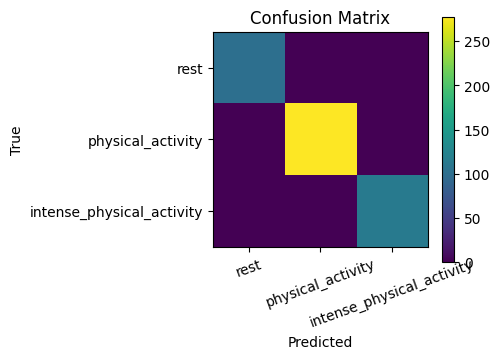

In [23]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1, 2], [LABEL_NAMES[i] for i in range(3)], rotation=20)
plt.yticks([0, 1, 2], [LABEL_NAMES[i] for i in range(3)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

15. Feature importance

emg_mav_synth    0.288898
emg_rms_synth    0.255331
emg_wl_synth     0.216270
temp_synth       0.121704
hr_mean          0.026888
acc_energy       0.025492
acc_std          0.016464
gyro_mean        0.014612
gyro_std         0.014583
acc_mean         0.012995
hr_std           0.006763
dtype: float64


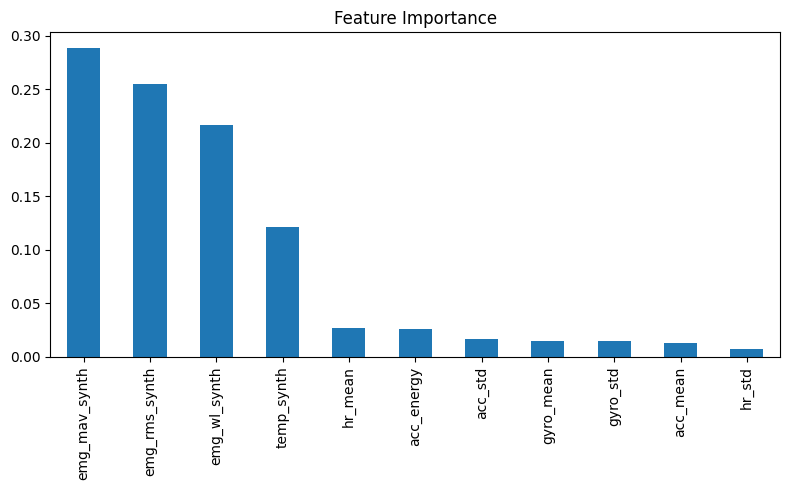

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

16. Save model

In [29]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/activity_classifier_rf.pkl")
print("Model saved.")

Model saved.


17. Save processed features

In [30]:
import os

os.makedirs("../data/processed", exist_ok=True)

features_df.to_csv("../data/processed/activity_fusion_features.csv", index=False)
print("Features saved.")

Features saved.


# Conclusions

- Built a 3-class classifier for:
    rest / physical activity / intense physical activity

- Used real PAMAP2 IMU + HR features

- Added synthetic EMG + temperature features for temporary fusion

# This notebook can later be upgraded by replacing synthetic EMG/temp with real prototype sensor features